<a href="https://colab.research.google.com/github/IsagiTegaYoichi/Glassdoor-Reviews-of-IT-Jobs/blob/main/Final_Dissertation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Reading the data
import pandas as pd
glass = pd.read_csv('glassdoor_reviews.csv')
#Showing data types of each column
print(glass.dtypes)

firm                    object
date_review             object
job_title               object
current                 object
location                object
overall_rating           int64
work_life_balance      float64
culture_values         float64
diversity_inclusion    float64
career_opp             float64
comp_benefits          float64
senior_mgmt            float64
recommend               object
ceo_approv              object
outlook                 object
headline                object
pros                    object
cons                    object
dtype: object


In [ ]:
#Preview of the data
glass.head()

,firm,date_review,job_title,current,location,overall_rating,work_life_balance,culture_values,diversity_inclusion,career_opp,comp_benefits,senior_mgmt,recommend,ceo_approv,outlook,headline,pros,cons
0,AFH-Wealth-Management,2015-04-05,,Current Employee,NaN,2,4.0,3.0,NaN,2.0,3.0,3.0,x,o,r,"Young colleagues, poor micro management",Very friendly and welcoming to new staff. Easy...,"Poor salaries, poor training and communication."
1,AFH-Wealth-Management,2015-12-11,Office Administrator,"Current Employee, more than 1 year","Bromsgrove, England, England",2,3.0,1.0,NaN,2.0,1.0,4.0,x,o,r,"Excellent staff, poor salary","Friendly, helpful and hard-working colleagues",Poor salary which doesn't improve much with pr...
2,AFH-Wealth-Management,2016-01-28,Office Administrator,"Current Employee, less than 1 year","Bromsgrove, England, England",1,1.0,1.0,NaN,1.0,1.0,1.0,x,o,x,"Low salary, bad micromanagement",Easy to get the job even without experience in...,"Very low salary, poor working conditions, very..."
3,AFH-Wealth-Management,2016-04-16,,Current Employee,NaN,5,2.0,3.0,NaN,2.0,2.0,3.0,x,o,r,Over promised under delivered,Nice staff to work with,No career progression and salary is poor
4,AFH-Wealth-Management,2016-04-23,Office Administrator,"Current Employee, more than 1 year","Bromsgrove, England, England",1,2.0,1.0,NaN,2.0,1.0,1.0,x,o,x,client reporting admin,"Easy to get the job, Nice colleagues.","Abysmal pay, around minimum wage. No actual tr..."


In [ ]:
#Changing Column Names
glass.rename(columns={
    'firm': 'companyName',
    'date_review': 'reviewDate',
    'job_title': 'jobtitle',
    'current': 'currentEmployeeStatus',
    'location': 'jobLocation',
    'overall_rating': 'overallRating',
    'work_life_balance': 'workLifeBalance',
    'culture_values': 'cultureValues',
    'diversity_inclusion': 'diversityInclusion',
    'career_opp': 'careerOpportunities',
    'comp_benefits': 'compensationBenefits',
    'senior_mgmt': 'seniorManagement',
    'recommend': 'recommendToFriend',
    'ceo_approv': 'ceoApproval',
    'outlook': 'companyOutlook',
    'headline': 'reviewHeadline',
    'pros': 'pros',
    'cons': 'cons'
}, inplace=True)

In [ ]:
glass.head()

,companyName,reviewDate,jobtitle,currentEmployeeStatus,jobLocation,overallRating,workLifeBalance,cultureValues,diversityInclusion,careerOpportunities,compensationBenefits,seniorManagement,recommendToFriend,ceoApproval,companyOutlook,reviewHeadline,pros,cons
0,AFH-Wealth-Management,2015-04-05,,Current Employee,NaN,2,4.0,3.0,NaN,2.0,3.0,3.0,x,o,r,"Young colleagues, poor micro management",Very friendly and welcoming to new staff. Easy...,"Poor salaries, poor training and communication."
1,AFH-Wealth-Management,2015-12-11,Office Administrator,"Current Employee, more than 1 year","Bromsgrove, England, England",2,3.0,1.0,NaN,2.0,1.0,4.0,x,o,r,"Excellent staff, poor salary","Friendly, helpful and hard-working colleagues",Poor salary which doesn't improve much with pr...
2,AFH-Wealth-Management,2016-01-28,Office Administrator,"Current Employee, less than 1 year","Bromsgrove, England, England",1,1.0,1.0,NaN,1.0,1.0,1.0,x,o,x,"Low salary, bad micromanagement",Easy to get the job even without experience in...,"Very low salary, poor working conditions, very..."
3,AFH-Wealth-Management,2016-04-16,,Current Employee,NaN,5,2.0,3.0,NaN,2.0,2.0,3.0,x,o,r,Over promised under delivered,Nice staff to work with,No career progression and salary is poor
4,AFH-Wealth-Management,2016-04-23,Office Administrator,"Current Employee, more than 1 year","Bromsgrove, England, England",1,2.0,1.0,NaN,2.0,1.0,1.0,x,o,x,client reporting admin,"Easy to get the job, Nice colleagues.","Abysmal pay, around minimum wage. No actual tr..."


In [ ]:
# Removing missing values
glass_cleaned = glass.dropna()

# Number of rows after removing missing values
num_rows_cleaned = glass_cleaned.shape[0]

print(f'The dataset has {num_rows_cleaned} rows after removing missing values.')

The dataset has 108544 rows after removing missing values.


# Filtering the data to only include select IT sector Jobs

In [ ]:
data = glass_cleaned[glass['jobtitle'].str.contains(
    r'\b(?:IT|Data Analyst|Data Scientist|Programmer|Network Engineer|Software Engineer|Cloud Engineer)\b',
    case=False,
    na=False
)]

<ipython-input-7-a4fdc178bca5>:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data = glass_cleaned[glass['jobtitle'].str.contains(


In [ ]:
# Total number of values after removing missing values
data_cleaned= data.dropna()
num_cleaned=data_cleaned.shape[0]

print(f"Total number of values after removing missing values: {num_cleaned}")

Total number of values after removing missing values: 5896


## Preprocessing

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
import nltk
nltk.download('punkt')
import re
import spacy
nlp = spacy.load('en_core_web_sm')
# Preprocessing function
stop_words = set(stopwords.words('english'))
def preprocess_text(text, use_stemming=False):
    # Convert text to lowercase
    text = text.lower()

    # Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)

    # Tokenize the text
    tokens = word_tokenize(text)

    # Remove stop words
    tokens = [word for word in tokens if word not in stop_words]

    # Apply lemmatization
    doc = nlp(' '.join(tokens))
    tokens = [token.lemma_ for token in doc]

    # Join tokens back into a single string
    preprocessed_text = ' '.join(tokens)

    return preprocessed_text

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
# Applying preprocessing to 'pros' and 'cons'
data_cleaned.loc[:,'pros_clean'] = data_cleaned['pros'].dropna().apply(preprocess_text)
data_cleaned.loc[:,'cons_clean'] = data_cleaned['cons'].dropna().apply(preprocess_text)

# Exploratory Analysis

## Word Cloud

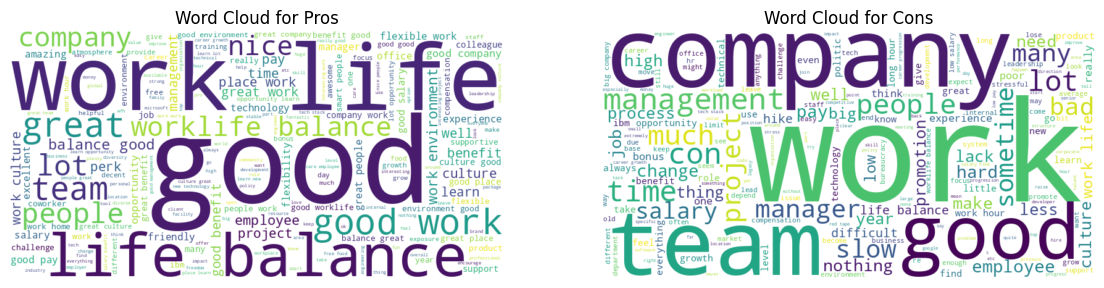

In [ ]:
# Word Clouds
# Word Frequency Analysis
from wordcloud import WordCloud
import matplotlib.pyplot as plt
pros_words = [word for sublist in data_cleaned['pros_clean'].apply(lambda x: x.split()) for word in sublist]
cons_words = [word for sublist in data_cleaned['cons_clean'].apply(lambda x: x.split()) for word in sublist]

pros_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(pros_words))
cons_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(cons_words))

plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
plt.imshow(pros_wordcloud, interpolation='bilinear')
plt.title('Word Cloud for Pros')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cons_wordcloud, interpolation='bilinear')
plt.title('Word Cloud for Cons')
plt.axis('off')

plt.show()

## Updated Text Preprocessing

In [ ]:
# Preprocessing function
stop_words2 = set(stopwords.words('english'))

# Add custom stop words
custom_stop_words = {'good', 'con', 'nice'}
stop_words2.update(custom_stop_words)

def preprocess_text2(text, use_stemming=False):
    # Convert text to lowercase
    text = text.lower()

    # Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)

    # Tokenize the text
    tokens = word_tokenize(text)

    # Remove stop words
    tokens = [word for word in tokens if word not in stop_words]

    # Apply lemmatization
    doc = nlp(' '.join(tokens))
    tokens = [token.lemma_ for token in doc]

    # Join tokens back into a single string
    preprocessed_text = ' '.join(tokens)

    return preprocessed_text

## Correlation Matrix

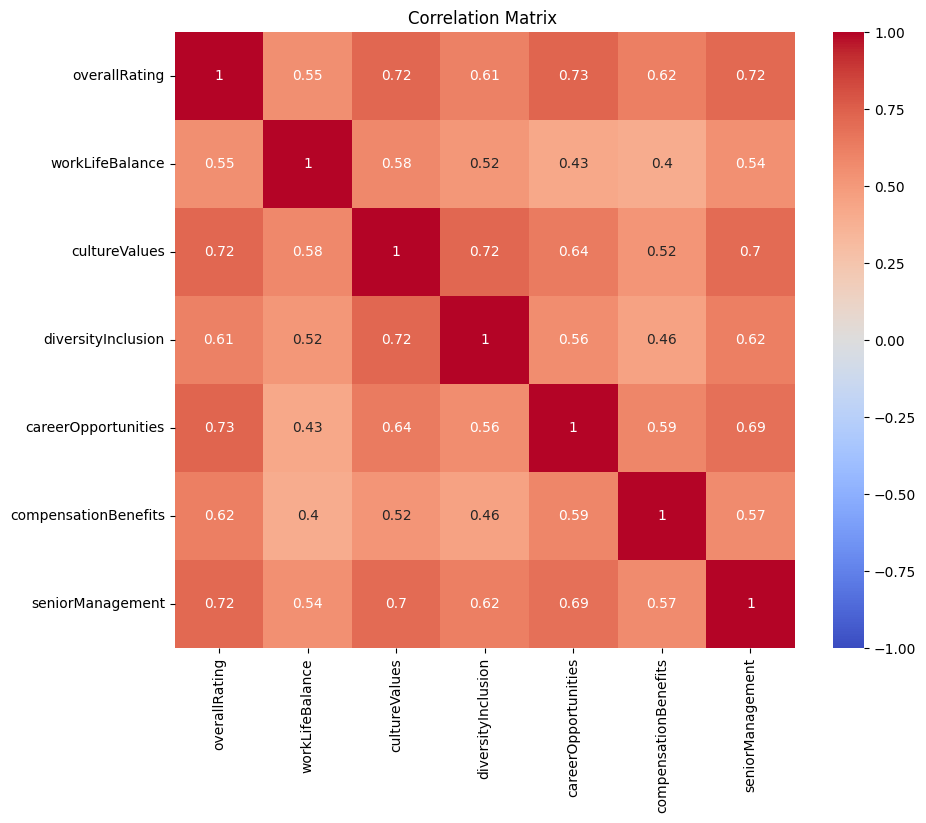

In [ ]:
import seaborn as sns
#CORRELATION MATRIX
# Selecting only numerical columns
numerical_columns = data.select_dtypes(include=['int64', 'float64']).columns
data_numerical = data[numerical_columns]
# Calculating the correlation matrix
corr_matrix = data_numerical.corr()
# heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Matrix ')
plt.show()

## Variance Inflation Factor

In [ ]:
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Excluding the target variable 'overall_Rating'
X = data_numerical.drop(columns=['overallRating']).dropna()

# Add a constant (intercept) to the predictors
X = add_constant(X)

# Create a DataFrame to store VIF values
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns

# Calculate VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display VIF results
print("Variance Inflation Factor (VIF):")
print(vif_data)

Variance Inflation Factor (VIF):
                Feature        VIF
0                 const  21.672605
1       workLifeBalance   1.632113
2         cultureValues   3.005992
3    diversityInclusion   2.268081
4   careerOpportunities   2.291409
5  compensationBenefits   1.697224
6      seniorManagement   2.676291


## Topic Modelling for 'Cons'

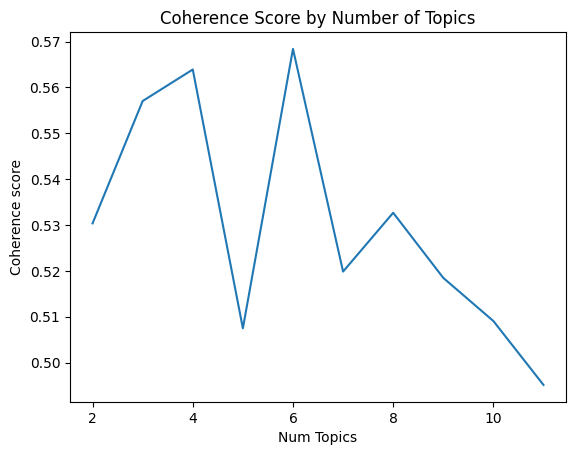

Optimal number of topics: 6
(0, '0.054*"con" + 0.026*"technology" + 0.024*"work" + 0.017*"old" + 0.017*"find" + 0.014*"team" + 0.012*"company" + 0.011*"slow" + 0.011*"need" + 0.011*"tech"')
(1, '0.032*"nothing" + 0.011*"get" + 0.011*"think" + 0.011*"team" + 0.010*"time" + 0.009*"not" + 0.008*"people" + 0.008*"manager" + 0.008*"work" + 0.008*"make"')
(2, '0.118*"work" + 0.032*"hour" + 0.028*"long" + 0.027*"balance" + 0.023*"life" + 0.017*"time" + 0.013*"pressure" + 0.013*"high" + 0.012*"1" + 0.011*"sometimes"')
(3, '0.025*"slow" + 0.025*"company" + 0.022*"lot" + 0.020*"get" + 0.019*"career" + 0.018*"hard" + 0.016*"process" + 0.015*"big" + 0.014*"many" + 0.013*"difficult"')
(4, '0.052*"not" + 0.043*"do" + 0.030*"much" + 0.028*"management" + 0.015*"work" + 0.014*"employee" + 0.010*"bad" + 0.009*"manager" + 0.008*"enough" + 0.008*"like"')
(5, '0.065*"salary" + 0.042*"low" + 0.037*"pay" + 0.031*"less" + 0.031*"hike" + 0.026*"company" + 0.021*"compare" + 0.020*"good" + 0.015*"compensation" +

In [ ]:
from sklearn import metrics
from gensim import corpora
from gensim.models.ldamodel import LdaModel
import gensim
from gensim.models import CoherenceModel
# Applying updated preprocessing
data_cleaned['processed_cons'] = data_cleaned['cons'].dropna().apply(preprocess_text2)
# Create a dictionary representation of the documents
tokenized_cons = [doc.split() for doc in data_cleaned['processed_cons']]
dictionary = corpora.Dictionary(tokenized_cons)

# Filter out extremes to limit the number of features
dictionary.filter_extremes(no_below=1, no_above=0.5)

# Create a bag-of-words representation of the documents
corpus = [dictionary.doc2bow(doc) for doc in tokenized_cons]

# compute coherence score for a given number of topics
def compute_coherence_values(dictionary, corpus, texts, start, limit, step):
    coherence_values = []
    model_list = []
    for num_topics in range(start, limit, step):
        model = LdaModel(corpus=corpus, num_topics=num_topics, id2word=dictionary, passes=15, random_state=42)
        model_list.append(model)
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())
    return model_list, coherence_values

# Define parameters
start = 2    # Minimum number of topics
limit = 12   # Maximum number of topics (you can increase this limit)
step = 1     # Step size

# Compute coherence values
# Ensure that 'texts' is also tokenized
tokenized_texts = [doc.split() for doc in data_cleaned['processed_cons']]
model_list, coherence_values = compute_coherence_values(dictionary=dictionary, corpus=corpus, texts=tokenized_texts, start=start, limit=limit, step=step)

# Plot coherence values
x = range(start, limit, step)
plt.plot(x, coherence_values)
plt.xlabel("Num Topics")
plt.ylabel("Coherence score")
plt.title("Coherence Score by Number of Topics")
plt.show()

# Select the model with the highest coherence value
optimal_num_topics = x[coherence_values.index(max(coherence_values))]
optimal_model = model_list[coherence_values.index(max(coherence_values))]

print(f"Optimal number of topics: {optimal_num_topics}")

# Extract and print the topics with the optimal number of topics
topics = optimal_model.print_topics(num_words=10)
for topic in topics:
    print(topic)


# Assuming you've already found the optimal number of topics and have the optimal_model
topics = optimal_model.print_topics(num_words=10)

# Prepare the data for the table
topic_words = []
for topic_num, topic_words_str in topics:
    # Extract the words from the topic string
    words = [word.split('*')[1].strip('"') for word in topic_words_str.split(' + ')]
    topic_words.append(words)

# Manually add descriptions for each topic
topic_descriptions = [
    "Outdated Technology",
    "Lack of Direction",
    "Work-Life Balance Issues",
    "Slow Career Progression",
    "Poor Management" ,
    "Low Salary and Compensation Concerns",

]

# Create a DataFrame from the topic words
df_topics = pd.DataFrame(topic_words)
df_topics.columns = [f'Word {i+1}' for i in range(df_topics.shape[1])]
df_topics.index = [f'Topic {i+1}' for i in range(df_topics.shape[0])]

# Add the descriptions as a new column
df_topics.insert(0, "Description", topic_descriptions)

# Convert DataFrame to LaTeX
latex_table = df_topics.to_latex(index=True, header=True)

# Print the LaTeX code
print(latex_table)





## Topic Modelling for 'Pros'

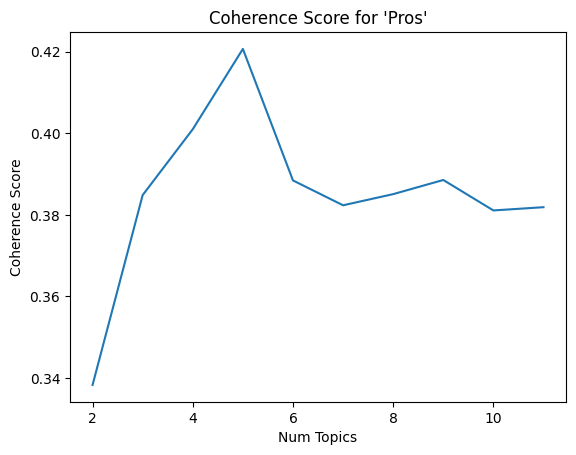

Optimal number of topics: 5
\begin{tabular}{llllllllllll}
\toprule
 & Description & Word 1 & Word 2 & Word 3 & Word 4 & Word 5 & Word 6 & Word 7 & Word 8 & Word 9 & Word 10 \\
\midrule
Topic 1 & 1 & work & team & company & learn & opportunity & lot & job & many & new & people \\
Topic 2 & 2 & opportunity & lot & good & great & learn & career & growth & benefit & free & training \\
Topic 3 & 3 & good & great & salary & benefit & work & people & pay & culture & flexible & hour \\
Topic 4 & 4 & work & good & balance & life & great & environment & culture & people & place & company \\
Topic 5 & 5t & employee & company & care & good & time & health & provide & benefit & not & like \\
\bottomrule
\end{tabular}



In [ ]:
# Preprocess the 'Pros' column
data_cleaned['processed_pros'] = data_cleaned['pros'].dropna().apply(preprocess_text2)

# Tokenize the processed 'Pros' data
tokenized_pros = [doc.split() for doc in data_cleaned['processed_pros']]

# Create a dictionary representation of the documents
dictionary2 = corpora.Dictionary(tokenized_pros)

# Filter out extremes to limit the number of features
dictionary2.filter_extremes(no_below=1, no_above=0.5)

# Create a bag-of-words representation of the documents
corpus2 = [dictionary2.doc2bow(doc) for doc in tokenized_pros]

# Function to compute coherence score for a given number of topics
def compute_coherence_values(dictionary, corpus, texts, start, limit, step):
    coherence_values = []
    model_list = []
    for num_topics in range(start, limit, step):
        model = LdaModel(corpus=corpus, num_topics=num_topics, id2word=dictionary, passes=15, random_state=42)
        model_list.append(model)
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())
    return model_list, coherence_values

# Define parameters for coherence value computation
start = 2    # Minimum number of topics
limit = 12   # Maximum number of topics
step = 1     # Step size

# Compute coherence values
tokenized_texts2 = [doc.split() for doc in data_cleaned['processed_pros']]
model_list2, coherence_values2 = compute_coherence_values(dictionary=dictionary2, corpus=corpus2, texts=tokenized_texts2, start=start, limit=limit, step=step)

# Plot coherence values
x2 = range(start, limit, step)
plt.plot(x2, coherence_values2)
plt.xlabel("Num Topics")
plt.ylabel("Coherence Score")
plt.title("Coherence Score for 'Pros'")
plt.show()

# Select the model with the highest coherence value
optimal_num_topics2 = x2[coherence_values2.index(max(coherence_values2))]
optimal_model2 = model_list2[coherence_values2.index(max(coherence_values2))]

print(f"Optimal number of topics: {optimal_num_topics2}")

# Extract topics with the optimal number of topics
topics2 = optimal_model2.show_topics(num_topics=optimal_num_topics2, num_words=10, formatted=False)

# Prepare the data for the table
topic_words2 = []
for topic_num, topic_words in topics2:  # Note: topic_words is now a list of tuples
    # Extract the words from the topic tuples
    words = [word[0] for word in topic_words]  # Extract the first element (word) from each tuple
    topic_words2.append(words)

# Manually add descriptions for each topic
topic_descriptions2 = [
    "1",
    "2",
    "3",
    "4",
    "5t",
    "6",
    # Add more descriptions if there are more topics
]

# Create a DataFrame from the topic words
df_topics2 = pd.DataFrame(topic_words2)
df_topics2.columns = [f'Word {i+1}' for i in range(df_topics2.shape[1])]
df_topics2.index = [f'Topic {i+1}' for i in range(df_topics2.shape[0])]

# Add the descriptions as a new column
df_topics2.insert(0, "Description", topic_descriptions2[:len(df_topics2)])

# Convert DataFrame to LaTeX
latex_table2 = df_topics2.to_latex(index=True, header=True)

# Print the LaTeX code
print(latex_table2)


## Random forest Model

Classification Report:
               precision    recall  f1-score   support

           1       0.68      0.70      0.69        46
           2       0.45      0.32      0.37        66
           3       0.48      0.51      0.49       187
           4       0.60      0.64      0.62       389
           5       0.79      0.77      0.78       492

    accuracy                           0.66      1180
   macro avg       0.60      0.59      0.59      1180
weighted avg       0.66      0.66      0.66      1180

Accuracy Score: 0.6559322033898305
General Precision: 0.6567
General Recall: 0.6559
General F1 Score: 0.6554


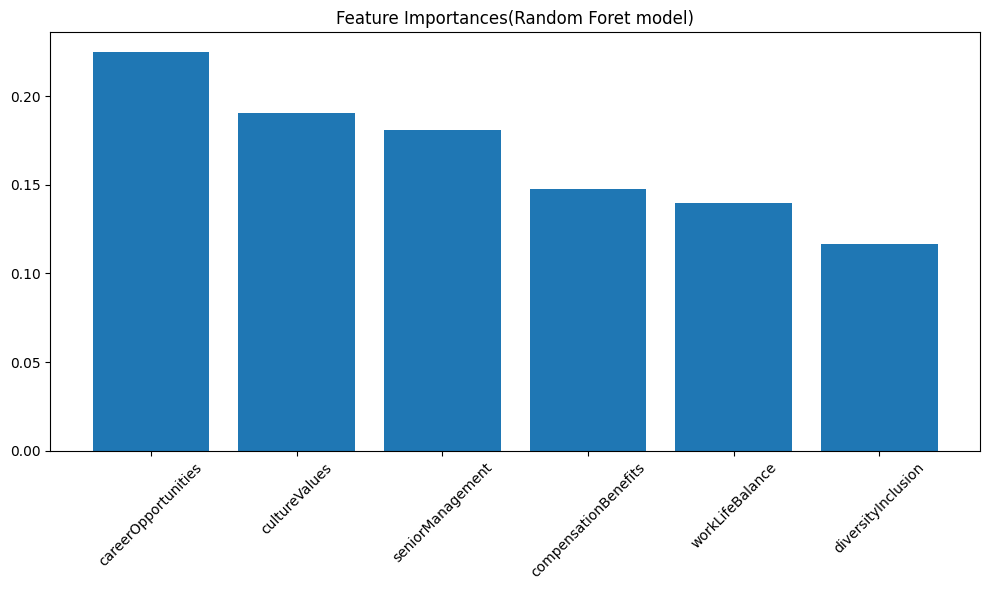

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Define X (features) and y (target)
X = data_numerical.drop('overallRating', axis=1)  # Drop target from features
y = data_numerical['overallRating']

# Drop rows with missing values
X = X.dropna()
y = y.loc[X.index]

# Split the dataset into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Generate the classification report and accuracy score
classification_report_general = classification_report(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

# Display the classification report and accuracy
print("Classification Report:\n", classification_report_general)
print("Accuracy Score:", accuracy)



# Calculate general precision, recall, and F1 score
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Display the precision, recall, and F1 score
print(f"General Precision: {precision:.4f}")
print(f"General Recall: {recall:.4f}")
print(f"General F1 Score: {f1:.4f}")

# Feature importance
importances = rf_classifier.feature_importances_

# Sort the feature importances in descending order and get the indices
indices = np.argsort(importances)[::-1]

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.title("Feature Importances(Random Foret model)")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), [X.columns[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()





## XGBoost

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [09:57:55] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.70      0.67        46
           1       0.51      0.33      0.40        66
           2       0.51      0.50      0.51       187
           3       0.60      0.69      0.64       389
           4       0.80      0.75      0.77       492

    accuracy                           0.66      1180
   macro avg       0.61      0.59      0.60      1180
weighted avg       0.67      0.66      0.66      1180

Accuracy Score: 0.6627118644067796


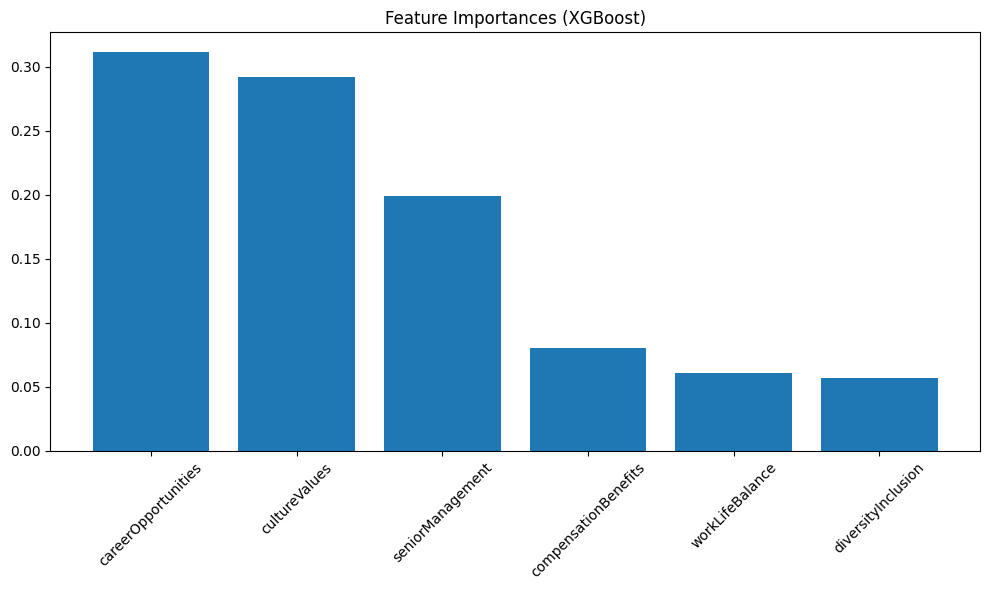

General Precision: 0.6665
General Recall: 0.6627
General F1 Score: 0.6622


In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb



# Define features (inputs) and target (output)
features = data_numerical.drop('overallRating', axis=1)  # Drop target column from features
target = data_numerical['overallRating'] - 1  # Shift target values to 0-based

# Drop rows with missing values
features_clean = features.dropna()
target_clean = target.loc[features_clean.index]

# Split the dataset into training and test sets (80% train, 20% test)
features_train, features_test, target_train, target_test = train_test_split(
    features_clean, target_clean, test_size=0.2, random_state=42
)

# Initialize the XGBoost Classifier
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# Train the model
xgb_model.fit(features_train, target_train)

# Make predictions on the test set
target_pred = xgb_model.predict(features_test)

# Generate the classification report and accuracy score
report = classification_report(target_test, target_pred)
accuracy_value = accuracy_score(target_test, target_pred)

# Display the classification report and accuracy
print("Classification Report:\n", report)
print("Accuracy Score:", accuracy_value)

# Feature importance
feature_importance = xgb_model.feature_importances_

# Sort the feature importances in descending order and get the indices
sorted_indices = np.argsort(feature_importance)[::-1]

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.title("Feature Importances (XGBoost)")
plt.bar(range(features_train.shape[1]), feature_importance[sorted_indices], align="center")
plt.xticks(range(features_train.shape[1]), [features_clean.columns[i] for i in sorted_indices], rotation=45)
plt.tight_layout()
plt.show()

from sklearn.metrics import precision_score, recall_score, f1_score
# Calculate general precision, recall, and F1 score
precision = precision_score(target_test, target_pred, average='weighted')
recall = recall_score(target_test, target_pred, average='weighted')
f1 = f1_score(target_test, target_pred, average='weighted')

# Display the precision, recall, and F1 score
print(f"General Precision: {precision:.4f}")
print(f"General Recall: {recall:.4f}")
print(f"General F1 Score: {f1:.4f}")